/tmp/ipykernel_2077/2077321120.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[objs] = df[objs].replace({'yes':1,"no":0})


1324506.9600914402
1754318687330.668
0.6529242642153176


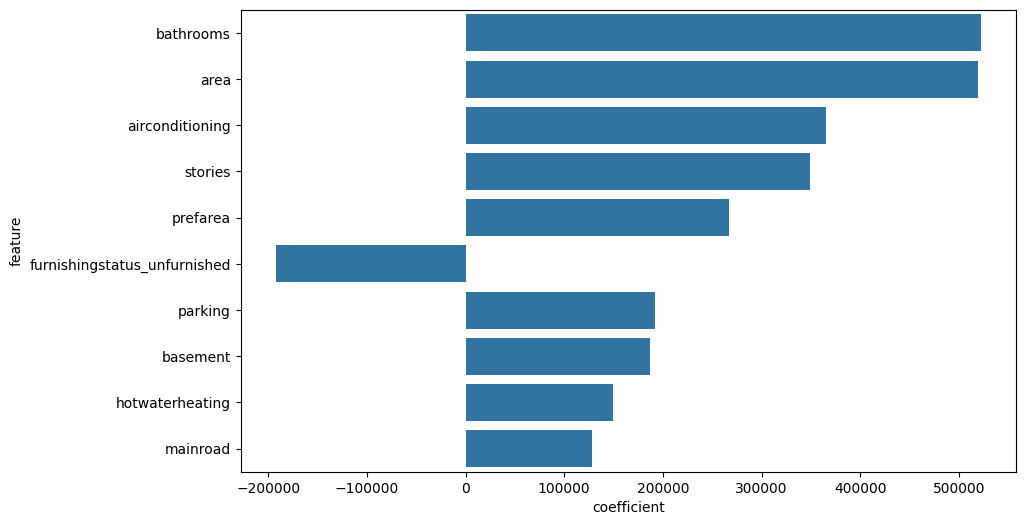

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('/content/Housing.csv')
objs = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[objs] = df[objs].replace({'yes':1,"no":0})
df= pd.get_dummies(df,columns=['furnishingstatus'],drop_first=True)

X= df.drop('price',axis=1)
y= df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_scaler = StandardScaler()
X_train= x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train,y_train)
y_pred= model.predict(X_test)

imp = pd.DataFrame({
    'feature':X.columns,
    'coefficient':model.coef_
})
imp['abs']= imp['coefficient'].abs()
imp = imp.sort_values(by='abs',ascending=False)
plt.figure(figsize=(10,6))

sns.barplot(
    x='coefficient',
    y='feature',
    data=imp.head(10)
)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))